In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 生成不同mueextmean的npy, 已将慢纺锤调至慢波的后半周期以后

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

def run_parameter_sweep(config):
    """
    运行参数扫描
    config: 字典，包含所有参数
    """
    # 解包配置
    n_runs = config['n_runs']
    c2tsc = config['c2tsc']              # 定值
    scale2 = config['scale2']            # 定值
    param_name = config['param_name']    # 要扫描的参数名
    param_list = config['param_list']    # 要扫描的参数值列表
    data_dir = config['data_dir']        # 保存目录
    
    # 创建保存目录
    os.makedirs(data_dir, exist_ok=True)
    
    # 统计已完成文件（跳过已存在的）
    existing_files = set()
    for f in os.listdir(data_dir):
        if f.endswith(".npy"):
            existing_files.add(f)
    
    total_tasks = len(param_list) * n_runs
    completed = len([f for f in existing_files if param_name in f])
    print(f"总任务数: {total_tasks}, 已完成: {completed}, 待运行: {total_tasks - completed}")
    
    for param_val in param_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_{param_name}_{param_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(data_dir, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            #params["c2tsc"] = c2tsc
            #params["scale2"] = scale2
            params["mue_ext_mean"] = param_val #这里一定要把正确的参数改掉

            params["Jet"] = 78.2 #18 * 0.8 #1.98
            params["Jer"] = 162 #0.23 * 0.8 #3.24
            params["c2tsc"] = 0.8
            params["scale2"] = 0.0005 #0.0013

            a = 8.4 #9.5
            params["VT_t"] = 26 -a#26 -9
            params["VT_r"] = 23 -a#23
            params["VB_t"] = 15 -a#15
            params["VB_r"] = 15 -a#15
            params["Jrt"] = -0.6 #-1.5 # -0.5
                        
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                param_name: param_val,
                "seed": seed
            })
            print(f"Saved: {param_name}={param_val:.4f}, seed={seed}")

# ========== 使用示例 ==========

# 示例1：扫描 mue_ext_mean
config_mue = {
    'n_runs': 20,
    'c2tsc': 1,
    'scale2': 0.0005,
    'param_name': 'mueextmean',
    'param_list': np.linspace(1.5,3.3,19),
    'data_dir': "data/raw_data_explore_mueextmean_slow_c2tsc0x8",
}





# 运行（取消注释需要的）
run_parameter_sweep(config_mue)

总任务数: 380, 已完成: 0, 待运行: 380
Saved: mueextmean=1.5000, seed=1
Saved: mueextmean=1.5000, seed=2
Saved: mueextmean=1.5000, seed=3
Saved: mueextmean=1.5000, seed=4
Saved: mueextmean=1.5000, seed=5
Saved: mueextmean=1.5000, seed=6
Saved: mueextmean=1.5000, seed=7
Saved: mueextmean=1.5000, seed=8
Saved: mueextmean=1.5000, seed=9
Saved: mueextmean=1.5000, seed=10
Saved: mueextmean=1.5000, seed=11
Saved: mueextmean=1.5000, seed=12
Saved: mueextmean=1.5000, seed=13
Saved: mueextmean=1.5000, seed=14
Saved: mueextmean=1.5000, seed=15
Saved: mueextmean=1.5000, seed=16
Saved: mueextmean=1.5000, seed=17
Saved: mueextmean=1.5000, seed=18
Saved: mueextmean=1.5000, seed=19
Saved: mueextmean=1.5000, seed=20
Saved: mueextmean=1.6000, seed=1
Saved: mueextmean=1.6000, seed=2
Saved: mueextmean=1.6000, seed=3
Saved: mueextmean=1.6000, seed=4
Saved: mueextmean=1.6000, seed=5
Saved: mueextmean=1.6000, seed=6
Saved: mueextmean=1.6000, seed=7
Saved: mueextmean=1.6000, seed=8
Saved: mueextmean=1.6000, seed=9
Save

In [3]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/mueextmean for20251128_11:10isdone')


#### 新增：分析快慢的耦合比例

读取 2976 个纺锤波
过滤后 2976 个纺锤波
参数值: [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]

汇总统计:
    mueextmean_slow_c2tsc0x8  fast_total_mean  fast_total_std  \
0                        1.5             0.95        0.825578   
1                        1.6             0.75        0.716350   
2                        1.7             0.70        0.864505   
3                        1.8             0.70        0.864505   
4                        1.9             0.50        0.760886   
5                        2.0             0.85        0.745160   
6                        2.1             1.65        1.348488   
7                        2.2             2.20        1.794729   
8                        2.3             2.25        1.371707   
9                        2.4             3.85        1.631112   
10                       2.5             3.70        1.301821   
11                       2.6             4.80        1.673320   
12                  

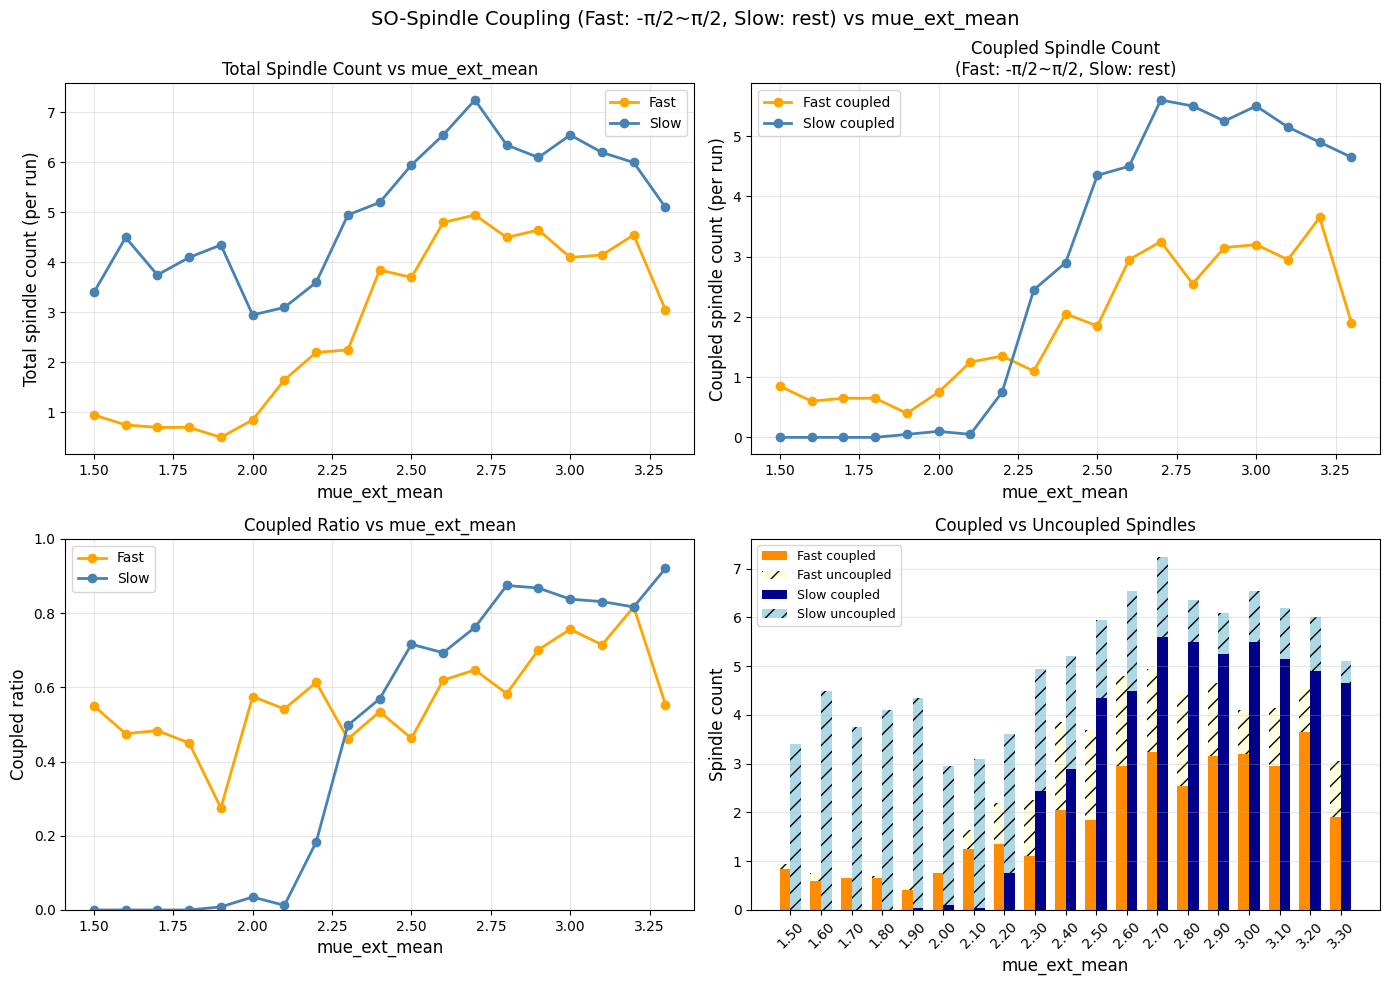


统计摘要 (mue_ext_mean)

1.500:
  Fast: total=0.9±0.8, coupled=0.8±0.9, ratio=0.550±0.510
  Slow: total=3.4±1.9, coupled=0.0±0.0, ratio=0.000±0.000

1.600:
  Fast: total=0.8±0.7, coupled=0.6±0.7, ratio=0.475±0.499
  Slow: total=4.5±2.5, coupled=0.0±0.0, ratio=0.000±0.000

1.700:
  Fast: total=0.7±0.9, coupled=0.7±0.7, ratio=0.483±0.501
  Slow: total=3.8±1.5, coupled=0.0±0.0, ratio=0.000±0.000

1.800:
  Fast: total=0.7±0.9, coupled=0.7±0.9, ratio=0.450±0.510
  Slow: total=4.1±1.9, coupled=0.0±0.0, ratio=0.000±0.000

1.900:
  Fast: total=0.5±0.8, coupled=0.4±0.7, ratio=0.275±0.444
  Slow: total=4.3±1.7, coupled=0.1±0.2, ratio=0.008±0.037

2.000:
  Fast: total=0.8±0.7, coupled=0.8±0.7, ratio=0.575±0.494
  Slow: total=3.0±1.5, coupled=0.1±0.3, ratio=0.035±0.118

2.100:
  Fast: total=1.6±1.3, coupled=1.2±1.3, ratio=0.542±0.449
  Slow: total=3.1±1.8, coupled=0.1±0.2, ratio=0.013±0.056

2.200:
  Fast: total=2.2±1.8, coupled=1.4±1.3, ratio=0.613±0.419
  Slow: total=3.6±1.8, coupled=0.8±1.0, ratio

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 参数设置 ==========
# 选择要分析的数据
# 选项1: mueextmean
CSV_PATH = "data/analysis_data/spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv"
PARAM_NAME = "mueextmean_slow_c2tsc0x8"
#CSV_PATH = "data/analysis_data/spindles_mueextmean_slow_explore_valid_limited.csv"
#PARAM_NAME = "mueextmean_slow"
PARAM_RANGE = (1.5, 3.3)
PARAM_LABEL = "mue_ext_mean"

# 选项2: cie (取消注释下面的，注释掉上面的)
# CSV_PATH = "data/analysis_data/spindles_cie_c2tsc0x8_Jrt0x6_explore_valid_limited.csv"
# PARAM_NAME = "cie_c2tsc0x8_Jrt0x6"
# PARAM_RANGE = (0.1, 1.5)
# PARAM_LABEL = "cie"

# ========== 新的耦合定义 ==========
# 快纺锤波：-π/2 到 π/2（Up state 附近）
# 慢纺锤波：剩下的相位（-π 到 -π/2 和 π/2 到 π，即 Down state 附近）
FAST_PHASE_LOW = -np.pi/2
FAST_PHASE_HIGH = np.pi/2

def is_coupled(phase, spindle_type):
    """判断纺锤波是否与 SO 耦合（基于相位区间）"""
    if spindle_type == 'fast':
        return FAST_PHASE_LOW <= phase <= FAST_PHASE_HIGH
    else:  # slow
        # 慢纺锤波在 -π ~ -π/2 或 π/2 ~ π
        return (phase >= -np.pi and phase <= -np.pi/2) or (phase >= np.pi/2 and phase <= np.pi)

# ========== 读取数据 ==========
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

# 过滤参数范围
df = df[(df[PARAM_NAME] >= PARAM_RANGE[0]) & (df[PARAM_NAME] <= PARAM_RANGE[1])]
print(f"过滤后 {len(df)} 个纺锤波")

# 获取参数值
param_values = sorted(df[PARAM_NAME].unique())
print(f"参数值: {param_values}")

# ========== 按 seed 和参数分组统计 ==========
results = []

for param_val in param_values:
    for seed in df['seed'].unique():
        subset = df[(df[PARAM_NAME] == param_val) & (df['seed'] == seed)]
        
        # 快纺锤波
        fast_subset = subset[subset['type'] == 'fast']
        fast_total = len(fast_subset)
        fast_phases = fast_subset['phase_at_peak'].dropna().values
        fast_coupled = sum(1 for p in fast_phases if is_coupled(p, 'fast'))
        
        # 慢纺锤波
        slow_subset = subset[subset['type'] == 'slow']
        slow_total = len(slow_subset)
        slow_phases = slow_subset['phase_at_peak'].dropna().values
        slow_coupled = sum(1 for p in slow_phases if is_coupled(p, 'slow'))
        
        results.append({
            PARAM_NAME: param_val,
            'seed': seed,
            'fast_total': fast_total,
            'fast_coupled': fast_coupled,
            'fast_ratio': fast_coupled / fast_total if fast_total > 0 else 0,
            'slow_total': slow_total,
            'slow_coupled': slow_coupled,
            'slow_ratio': slow_coupled / slow_total if slow_total > 0 else 0,
        })

df_results = pd.DataFrame(results)

# ========== 按参数汇总 ==========
summary = df_results.groupby(PARAM_NAME).agg(
    fast_total_mean=('fast_total', 'mean'),
    fast_total_std=('fast_total', 'std'),
    fast_coupled_mean=('fast_coupled', 'mean'),
    fast_coupled_std=('fast_coupled', 'std'),
    fast_ratio_mean=('fast_ratio', 'mean'),
    fast_ratio_std=('fast_ratio', 'std'),
    slow_total_mean=('slow_total', 'mean'),
    slow_total_std=('slow_total', 'std'),
    slow_coupled_mean=('slow_coupled', 'mean'),
    slow_coupled_std=('slow_coupled', 'std'),
    slow_ratio_mean=('slow_ratio', 'mean'),
    slow_ratio_std=('slow_ratio', 'std'),
    n_seeds=('seed', 'count'),
).reset_index()

print("\n汇总统计:")
print(summary)

# ========== 画图 ==========
param_vals = summary[PARAM_NAME].values
fast_total = summary['fast_total_mean'].values
fast_coupled = summary['fast_coupled_mean'].values
fast_ratio = summary['fast_ratio_mean'].values
slow_total = summary['slow_total_mean'].values
slow_coupled = summary['slow_coupled_mean'].values
slow_ratio = summary['slow_ratio_mean'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：纺锤波总数随参数变化
ax = axes[0, 0]
ax.plot(param_vals, fast_total, 'o-', color='orange', linewidth=2, markersize=6, label='Fast')
ax.plot(param_vals, slow_total, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow')
ax.set_xlabel(PARAM_LABEL, fontsize=12)
ax.set_ylabel('Total spindle count (per run)', fontsize=12)
ax.set_title(f'Total Spindle Count vs {PARAM_LABEL}', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图2：耦合数量随参数变化
ax = axes[0, 1]
ax.plot(param_vals, fast_coupled, 'o-', color='orange', linewidth=2, markersize=6, label='Fast coupled')
ax.plot(param_vals, slow_coupled, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow coupled')
ax.set_xlabel(PARAM_LABEL, fontsize=12)
ax.set_ylabel('Coupled spindle count (per run)', fontsize=12)
ax.set_title(f'Coupled Spindle Count\n(Fast: -π/2~π/2, Slow: rest)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 图3：耦合比例随参数变化
ax = axes[1, 0]
ax.plot(param_vals, fast_ratio, 'o-', color='orange', linewidth=2, markersize=6, label='Fast')
ax.plot(param_vals, slow_ratio, 'o-', color='steelblue', linewidth=2, markersize=6, label='Slow')
ax.set_xlabel(PARAM_LABEL, fontsize=12)
ax.set_ylabel('Coupled ratio', fontsize=12)
ax.set_title(f'Coupled Ratio vs {PARAM_LABEL}', fontsize=12)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

# 图4：堆叠柱状图（耦合 vs 未耦合）
ax = axes[1, 1]
x = np.arange(len(param_vals))
width = 0.35

# 快纺锤波
fast_uncoupled = fast_total - fast_coupled
slow_uncoupled = slow_total - slow_coupled

ax.bar(x - width/2, fast_coupled, width, color='darkorange', label='Fast coupled')
ax.bar(x - width/2, fast_uncoupled, width, bottom=fast_coupled, 
       color='lightyellow', label='Fast uncoupled', hatch='//')
ax.bar(x + width/2, slow_coupled, width, color='darkblue', label='Slow coupled')
ax.bar(x + width/2, slow_uncoupled, width, bottom=slow_coupled, 
       color='lightblue', label='Slow uncoupled', hatch='//')

ax.set_xlabel(PARAM_LABEL, fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title('Coupled vs Uncoupled Spindles', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.2f}' for v in param_vals], rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'SO-Spindle Coupling (Fast: -π/2~π/2, Slow: rest) vs {PARAM_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print(f"统计摘要 ({PARAM_LABEL})")
print("="*60)

for _, row in summary.iterrows():
    print(f"\n{row[PARAM_NAME]:.3f}:")
    print(f"  Fast: total={row['fast_total_mean']:.1f}±{row['fast_total_std']:.1f}, "
          f"coupled={row['fast_coupled_mean']:.1f}±{row['fast_coupled_std']:.1f}, "
          f"ratio={row['fast_ratio_mean']:.3f}±{row['fast_ratio_std']:.3f}")
    print(f"  Slow: total={row['slow_total_mean']:.1f}±{row['slow_total_std']:.1f}, "
          f"coupled={row['slow_coupled_mean']:.1f}±{row['slow_coupled_std']:.1f}, "
          f"ratio={row['slow_ratio_mean']:.3f}±{row['slow_ratio_std']:.3f}")

### spindles for param analysis (spindles_param_explore_valid_limited.csv)
- param = mue_ext_mean_slow
- c2tsc = 1; scale2 = 0.0005 / c2tsc = 0.8; scale2 = 0.0005
- param -> fast/slow spindles -> wax & wane

### 区分wax&wane之后

In [7]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这两行 ==========
DATA_FOLDER = "mueextmean_slow_c2tsc0x8"      # 数据文件夹名
PARAM_NAME = "mueextmean_slow_c2tsc0x8"       # 参数名
PARAM_RANGE = (1.5, 3.3)                      # 参数范围 (min, max)
# =================================

RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_PREFIX = f"spindles_{DATA_FOLDER}"

def get_phase_and_envelope(signal, filter_args, pad=None):
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    return phase.data.values, filtered, envelope

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t=None):
    """
    处理纺锤波检测结果
    新增：从原始 V_t 中提取 start→peak 和 peak→end 的振幅
    """
    results = []
    if sp is None:
        return results
    
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        overall_amplitude = row["Amplitude"]  # YASA 计算的整体振幅
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        # ===== 从原始 V_t 中计算 start→peak 和 peak→end 的振幅 =====
        # 截取信号片段
        start_segment = V_t[start_idx_sample:peak_idx_sample] if peak_idx_sample > start_idx_sample else np.array([0])
        end_segment = V_t[peak_idx_sample:end_idx_sample] if end_idx_sample > peak_idx_sample else np.array([0])
        
        # 计算各段的最大振幅（峰峰值：最大值 - 最小值）
        # 如果段长度小于2，直接用该点的值
        if len(start_segment) >= 2:
            start_to_peak_amp = np.max(start_segment) - np.min(start_segment)
        else:
            start_to_peak_amp = 0.0
        
        if len(end_segment) >= 2:
            peak_to_end_amp = np.max(end_segment) - np.min(end_segment)
        else:
            peak_to_end_amp = 0.0
        
        # 或者用 RMS 振幅（更稳定，但峰峰值更常用）
        # start_to_peak_amp = np.sqrt(np.mean(start_segment**2)) if len(start_segment) > 0 else 0
        
        phase_start = slow_phase_masked[start_idx]
        phase_peak = slow_phase_masked[peak_idx]
        phase_end = slow_phase_masked[end_idx]
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": overall_amplitude,              # 原有的整体振幅
            "start_to_peak_time": peak_time - start_time,
            "peak_to_end_time": end_time - peak_time,
            "start_to_peak_amp": start_to_peak_amp,      # 新增：上升段振幅
            "peak_to_end_amp": peak_to_end_amp,          # 新增：下降段振幅
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
            "envelope_at_start": envelope[start_idx],
            "envelope_at_peak": envelope[peak_idx],
            "envelope_at_end": envelope[end_idx],
            "masked": np.isnan(phase_peak),
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}
amplitude_threshold = 2

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM_NAME} 范围: {PARAM_RANGE}")
print(f"输出前缀: {OUTPUT_PREFIX}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    param_val = float(parts[5])
    seed = int(parts[7])
    
    if not (PARAM_RANGE[0] <= param_val <= PARAM_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM_NAME}={param_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    params = {PARAM_NAME: param_val, "c2tsc": c2tsc, "scale2": scale2, "seed": seed}
    
    # 传入 V_t 用于计算分段振幅
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked, V_t))
    
    print(f"  完成")

os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_limited.csv", index=False)

result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_valid_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"相位有效: {len(result_df_valid)} 个")

# 打印新增字段示例
if len(result_df) > 0:
    print("\n新增字段示例（第一条记录）:")
    cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp', 'amplitude']
    for col in cols:
        if col in result_df.columns:
            print(f"  {col}: {result_df[col].iloc[0]:.6f}")

找到 380 个文件
限定 mueextmean_slow_c2tsc0x8 范围: (1.5, 3.3)
输出前缀: spindles_mueextmean_slow_c2tsc0x8
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


  完成
Processing: mueextmean_slow_c2tsc0x8=1.5000, seed=11
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz


...

  完成
Processing: mueextmean_slow_c2tsc0x8=3.3000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: mueextmean_slow_c2tsc0x8=3.3000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成

总共检测到 4342 个纺锤波
相位有效: 2976 个

新增字段示例（第一条记录）:
  start_to_peak_time: 0.180100
  peak_to_end_time: 0.300400
  start_to_peak_amp: 4.728002
  peak_to_end_amp: 3.629363
  amplitude: 4.043038


### 画图 wax & wane

加载文件: spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv
分析参数: mueextmean_slow_c2tsc0x8
mueextmean_slow_c2tsc0x8 值: [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3]

按 seed 统计后的结果示例:
   mueextmean_slow_c2tsc0x8  seed  type  total_duration  count  mean_freq  \
0                       1.5     2  fast          1.1596      2  12.920803   
1                       1.5     2  slow          3.1685      6  10.590792   
2                       1.5     3  fast          1.1196      2  12.679434   
3                       1.5     3  slow          3.8528      3  11.308521   
4                       1.5     4  slow          2.9495      4  10.662040   

   std_freq  mean_duration  std_duration  mean_start_to_peak_time  \
0  0.428060       0.579800      0.358503                 0.343100   
1  0.466488       0.528083      0.292518                 0.257800   
2  0.496947       0.559800      0.217647                 0.192500   
3  0.238652       1.28

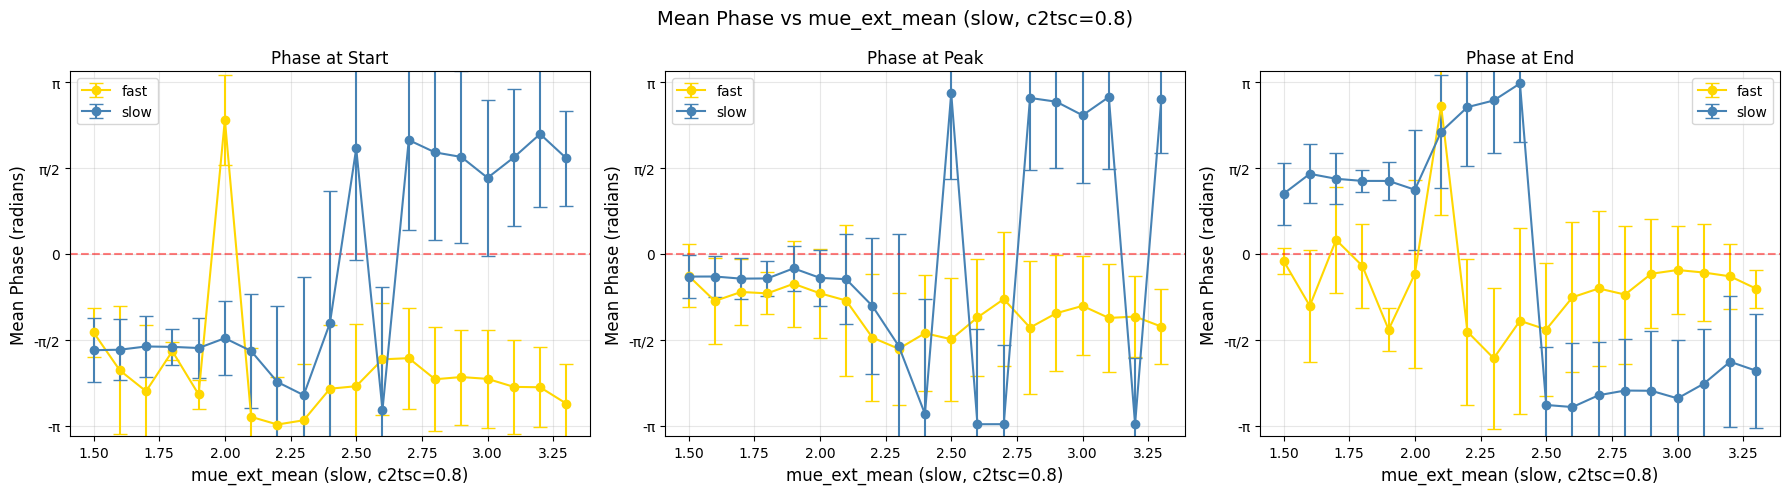

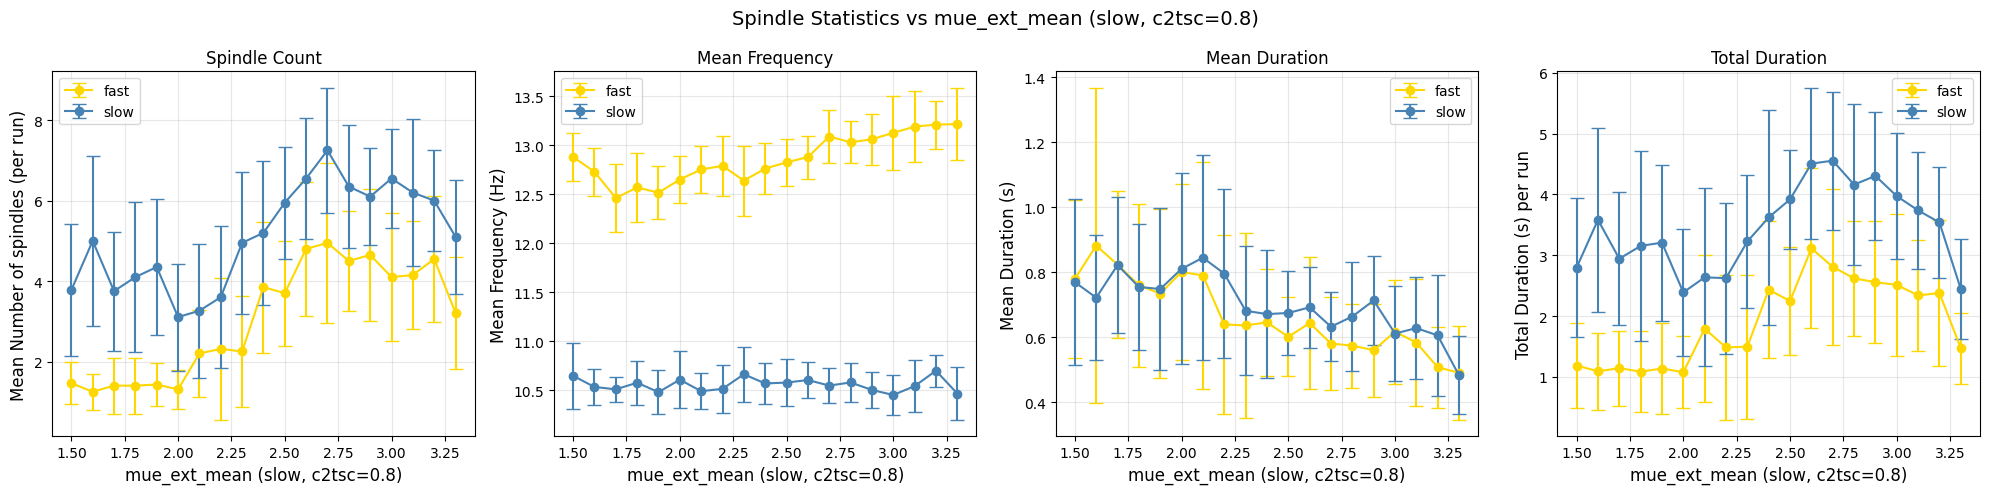

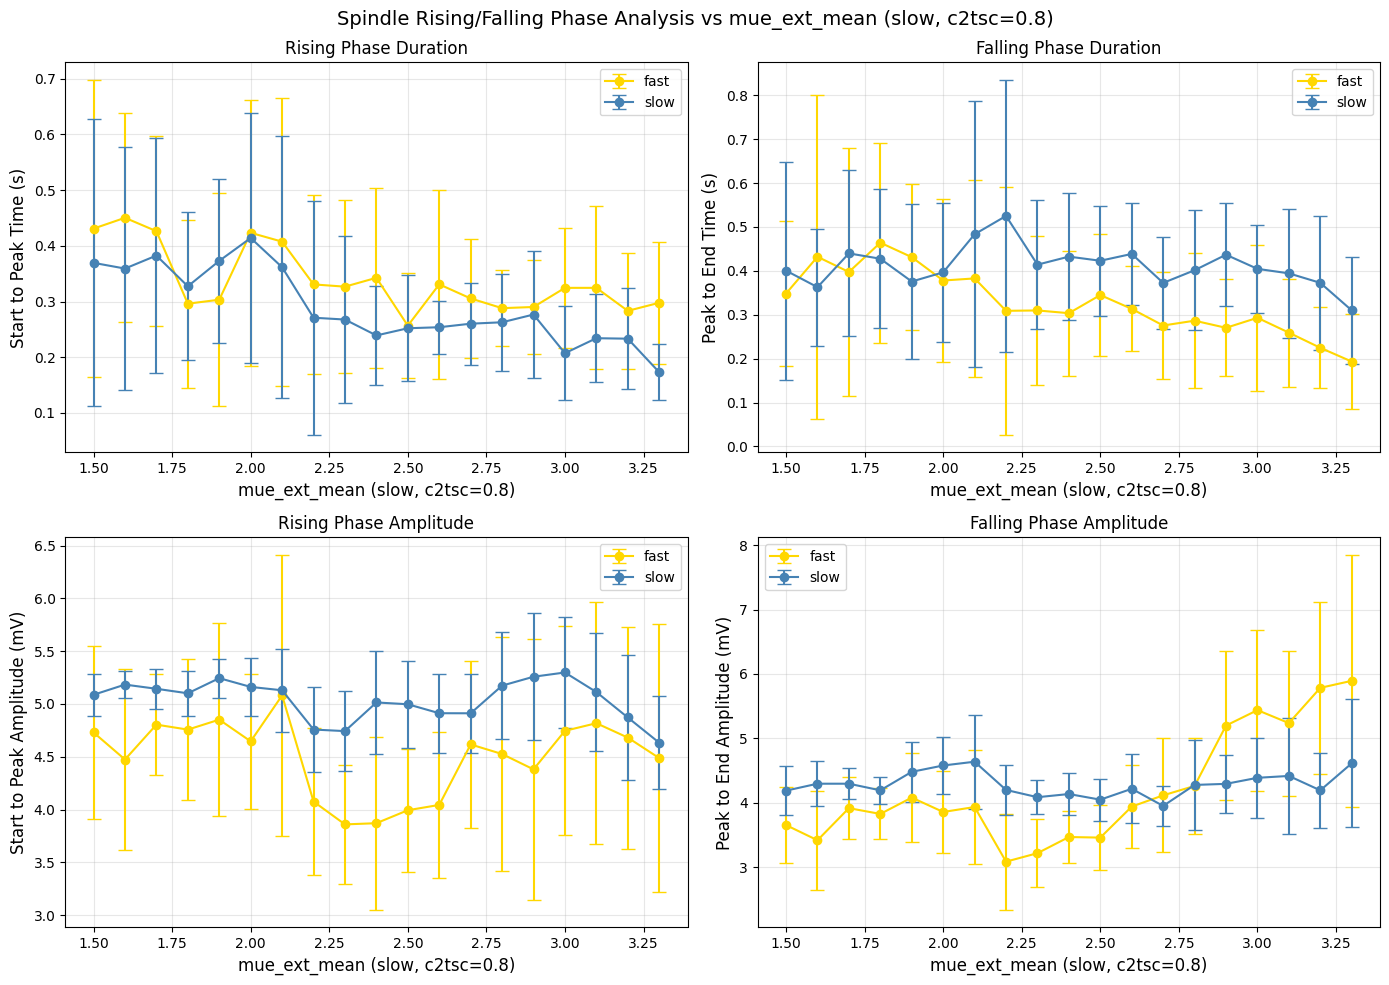


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mueextmean_slow_c2tsc0x8=1.50: seeds=13, count=1.5±0.5, rise_time=0.431±0.267s, fall_time=0.348±0.165s, rise_amp=4.730±0.822mV, fall_amp=3.652±0.594mV, phase=-0.401±0.579rad
  mueextmean_slow_c2tsc0x8=1.60: seeds=12, count=1.2±0.5, rise_time=0.450±0.187s, fall_time=0.432±0.369s, rise_amp=4.474±0.855mV, fall_amp=3.417±0.767mV, phase=-0.862±0.779rad
  mueextmean_slow_c2tsc0x8=1.70: seeds=10, count=1.4±0.7, rise_time=0.426±0.170s, fall_time=0.397±0.282s, rise_amp=4.804±0.475mV, fall_amp=3.915±0.486mV, phase=-0.697±0.605rad
  mueextmean_slow_c2tsc0x8=1.80: seeds=10, count=1.4±0.7, rise_time=0.296±0.151s, fall_time=0.464±0.228s, rise_amp=4.757±0.664mV, fall_amp=3.825±0.397mV, phase=-0.722±0.383rad
  mueextmean_slow_c2tsc0x8=1.90: seeds= 7, count=1.4±0.5, rise_time=0.303±0.191s, fall_time=0.431±0.167s, rise_amp=4.851±0.911mV, fall_amp=4.079±0.697mV, phase=-0.547±0.788rad
  mueextmean_slow_c2tsc0x8=2.00: seeds=13, count=1.3±0.5, rise_time=0.423±0.239

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "mueextmean_slow_c2tsc0x8"   # 可选: "mue_ext_mean", "tau_ou", "tau_se", "cee"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mueextmean": {
        "file": "spindles_mueextmean_explore_valid_limited.csv",
        "xlabel": "mueextmean",
        "save_prefix": "mueextmean",
    },
    "mueextmean_slow": {
        "file": "spindles_mueextmean_slow_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow)",
        "save_prefix": "mue_ext_mean_slow",
    },
    "mueextmean_slow_c2tsc0x8": {
        "file": "spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow, c2tsc=0.8)",
        "save_prefix": "mue_ext_mean_slow_c2tsc0x8",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 先计算每个 seed 的统计量，再求平均 ==========
# 按参数值和 seed 分组，计算每个 seed 的统计量（包括新的字段）
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('start_to_peak_time', 'mean'),
    std_start_to_peak_time=('start_to_peak_time', 'std'),
    mean_peak_to_end_time=('peak_to_end_time', 'mean'),
    std_peak_to_end_time=('peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('peak_to_end_amp', 'std'),
).reset_index()

# 再按参数值和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
    # ===== 新增：上升段和下降段的时间与振幅 =====
    mean_start_to_peak_time=('mean_start_to_peak_time', 'mean'),
    std_start_to_peak_time=('mean_start_to_peak_time', 'std'),
    mean_peak_to_end_time=('mean_peak_to_end_time', 'mean'),
    std_peak_to_end_time=('mean_peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('mean_start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('mean_start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('mean_peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('mean_peak_to_end_amp', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：四张汇总图（数量、频率、时长、总时长）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：新增四张子图（上升段时间、下降段时间、上升段振幅、下降段振幅）==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 子图1：上升段时间 (start_to_peak_time)
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_time'], 
                yerr=subset['std_start_to_peak_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Time (s)', fontsize=12)
ax.set_title('Rising Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：下降段时间 (peak_to_end_time)
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_time'], 
                yerr=subset['std_peak_to_end_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Time (s)', fontsize=12)
ax.set_title('Falling Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：上升段振幅 (start_to_peak_amp)
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_amp'], 
                yerr=subset['std_start_to_peak_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Amplitude (mV)', fontsize=12)
ax.set_title('Rising Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：下降段振幅 (peak_to_end_amp)
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_amp'], 
                yerr=subset['std_peak_to_end_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Amplitude (mV)', fontsize=12)
ax.set_title('Falling Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Rising/Falling Phase Analysis vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            # 新增统计
            mean_rise_time = subset['mean_start_to_peak_time'].mean()
            std_rise_time = subset['mean_start_to_peak_time'].std()
            mean_fall_time = subset['mean_peak_to_end_time'].mean()
            std_fall_time = subset['mean_peak_to_end_time'].std()
            mean_rise_amp = subset['mean_start_to_peak_amp'].mean()
            std_rise_amp = subset['mean_start_to_peak_amp'].std()
            mean_fall_amp = subset['mean_peak_to_end_amp'].mean()
            std_fall_amp = subset['mean_peak_to_end_amp'].std()
            
            # 相位统计（仍用原始数据）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                      f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                      f"phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                      f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                      f"no valid phase")

#### chirp

加载文件: spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv
分析参数: mueextmean_slow_c2tsc0x8
Raw 数据目录: data/raw_data_explore_mueextmean_slow_c2tsc0x8
['data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_1.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_10.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_11.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_12.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_13.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_14.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5000_seed_15.npy', 'data/raw_data_explore_mueextmean_slow_c2tsc0x8\\c2tsc_1.0000_scale2_0.0005_mueextmean_1.5

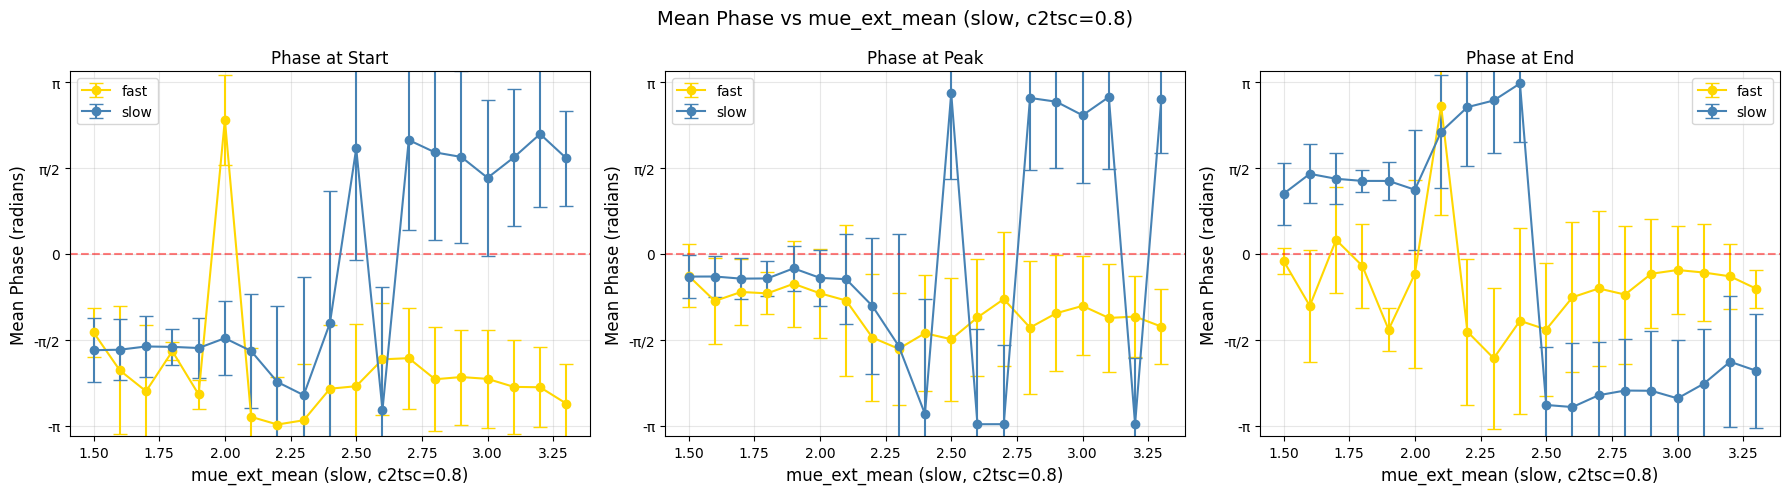

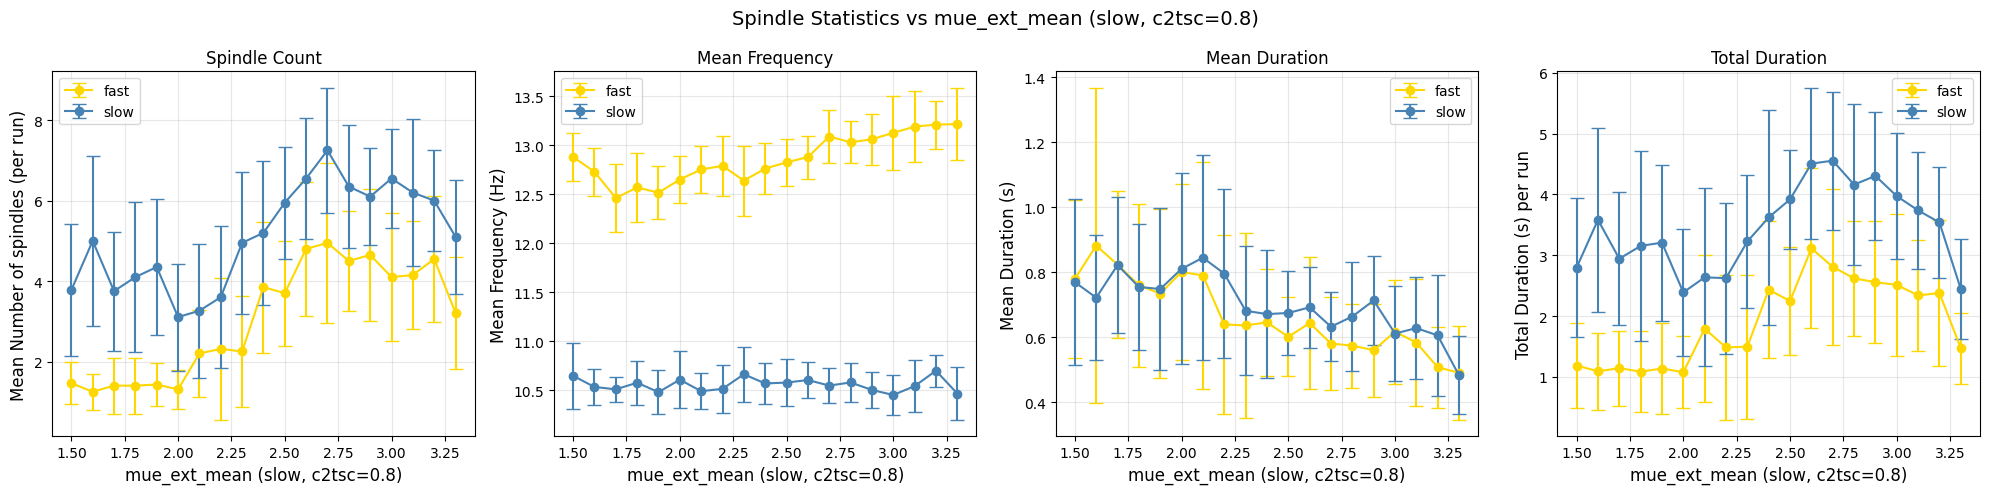

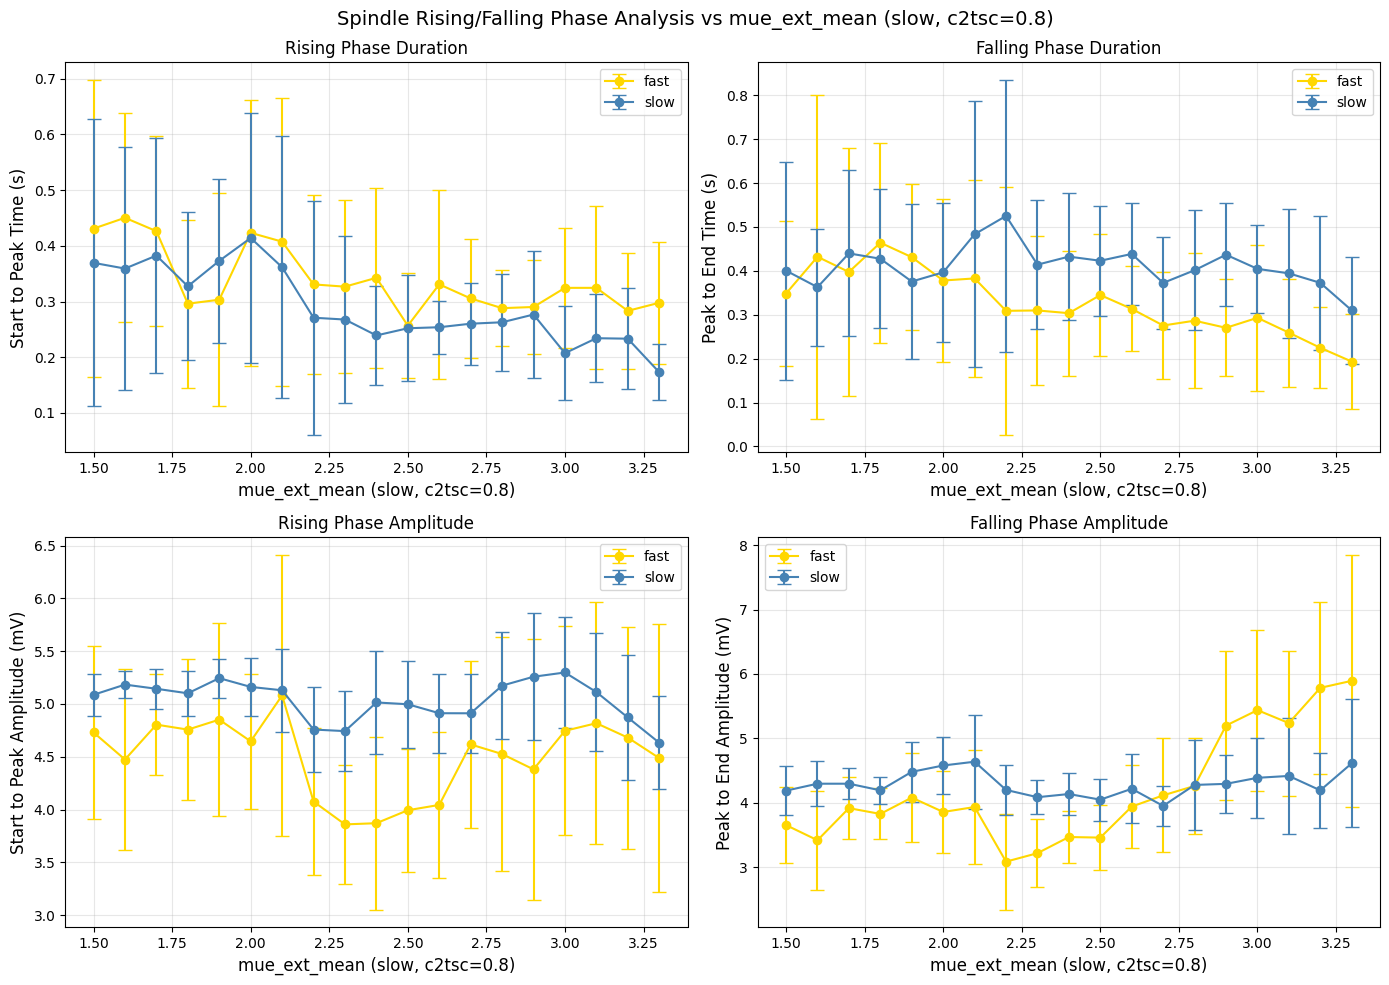

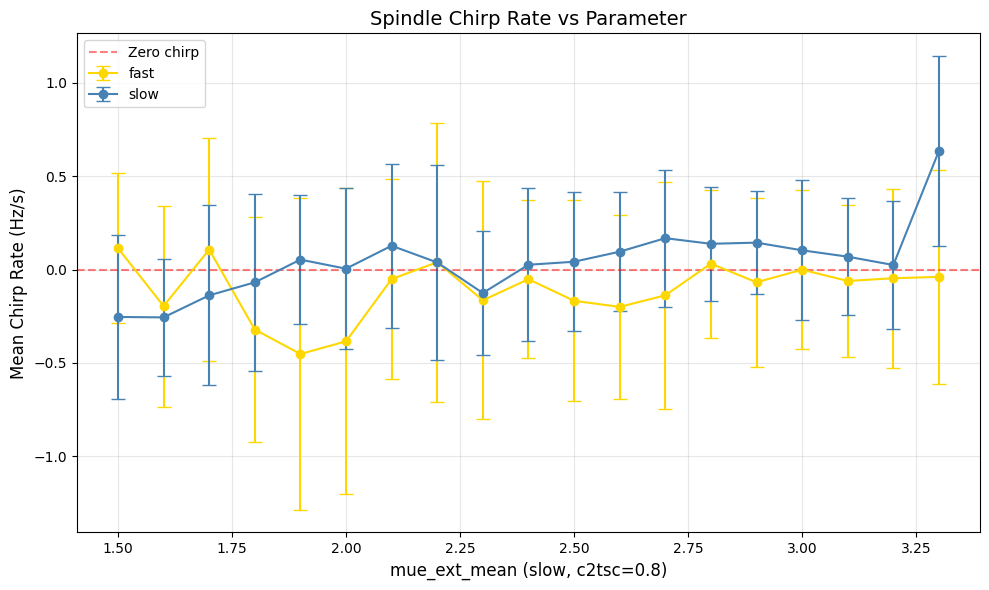

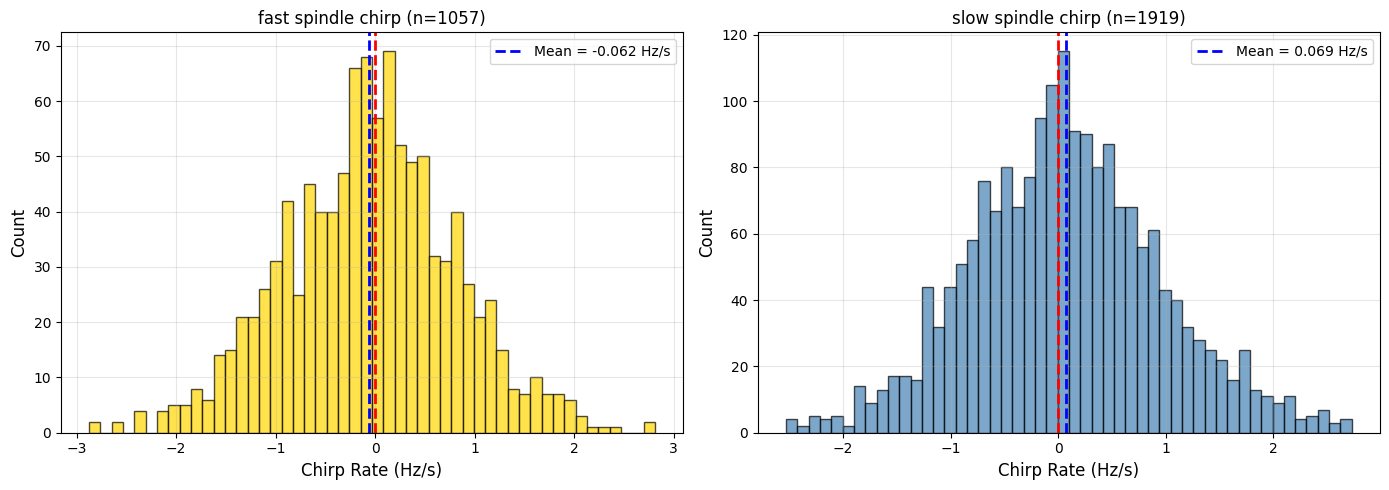


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mueextmean_slow_c2tsc0x8=1.50: seeds=13, count=1.5±0.5, chirp=0.114±0.402Hz/s, rise_time=0.431±0.267s, fall_time=0.348±0.165s, rise_amp=4.730±0.822mV, fall_amp=3.652±0.594mV, phase=-0.401±0.579rad
  mueextmean_slow_c2tsc0x8=1.60: seeds=12, count=1.2±0.5, chirp=-0.196±0.538Hz/s, rise_time=0.450±0.187s, fall_time=0.432±0.369s, rise_amp=4.474±0.855mV, fall_amp=3.417±0.767mV, phase=-0.862±0.779rad
  mueextmean_slow_c2tsc0x8=1.70: seeds=10, count=1.4±0.7, chirp=0.107±0.597Hz/s, rise_time=0.426±0.170s, fall_time=0.397±0.282s, rise_amp=4.804±0.475mV, fall_amp=3.915±0.486mV, phase=-0.697±0.605rad
  mueextmean_slow_c2tsc0x8=1.80: seeds=10, count=1.4±0.7, chirp=-0.321±0.603Hz/s, rise_time=0.296±0.151s, fall_time=0.464±0.228s, rise_amp=4.757±0.664mV, fall_amp=3.825±0.397mV, phase=-0.722±0.383rad
  mueextmean_slow_c2tsc0x8=1.90: seeds= 7, count=1.4±0.5, chirp=-0.452±0.834Hz/s, rise_time=0.303±0.191s, fall_time=0.431±0.167s, rise_amp=4.851±0.911mV, fall_am

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd
from scipy.fft import fft, fftfreq
import glob
import os
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import logging
logging.getLogger('mne').setLevel(logging.ERROR)

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "mueextmean_slow_c2tsc0x8"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mueextmean": {
        "file": "spindles_mueextmean_explore_valid_limited.csv",
        "xlabel": "mueextmean",
        "save_prefix": "mueextmean",
        "raw_dir": "data/raw_data_explore_mueextmean",
    },
    "mueextmean_slow": {
        "file": "spindles_mueextmean_slow_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow)",
        "save_prefix": "mue_ext_mean_slow",
        "raw_dir": "data/raw_data_explore_mueextmean_slow",
    },
    "mueextmean_slow_c2tsc0x8": {
        "file": "spindles_mueextmean_slow_c2tsc0x8_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean (slow, c2tsc=0.8)",
        "save_prefix": "mue_ext_mean_slow_c2tsc0x8",
        "raw_dir": "data/raw_data_explore_mueextmean_slow_c2tsc0x8",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
        "raw_dir": "data/raw_data_explore_tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
        "raw_dir": "data/raw_data_explore_tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
        "raw_dir": "data/raw_data_explore_cee",
    },
}

config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
RAW_DIR = config["raw_dir"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")
print(f"Raw 数据目录: {RAW_DIR}")

# ========== 读取 CSV ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

# ========== neurolib-style filtering helper ==========
def get_phase_and_filtered(signal, filter_args, pad=None):
    """返回相位和滤波后的信号（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values, filtered


def filter_signal_neurolib(data, sf, low_freq, high_freq, pad_seconds=0.5):
    """
    Filter a 1-D numpy array using neurolib's Signal class.
    """
    time_sec = np.arange(len(data)) / sf
    xr_data = xr.DataArray(data, dims=["time"], coords={"time": time_sec})
    sig = RatesSignal(xr_data)

    filter_args = {"low_freq": low_freq, "high_freq": high_freq}
    _, filtered = get_phase_and_filtered(sig, filter_args=filter_args, pad=pad_seconds)
    return filtered


# ========== Chirp 计算函数 ==========
def compute_chirp_wft(signal, fs, freq_band=(8, 16), n_steps=13,
                       window_sec=0.5, n_fft=2**16):
    """
    Compute chirp rate (Hz/s) using windowed FFT.
    Filtering is done via neurolib Signal (with reflect padding).
    """
    try:
        # 1. Filter using neurolib (pad 0.5 s on both sides)
        filtered = filter_signal_neurolib(
            signal, fs,
            low_freq=freq_band[0],
            high_freq=freq_band[1],
            pad_seconds=0.5,
        )

        # 2. Sliding window
        window_samples = int(window_sec * fs)
        if len(filtered) < window_samples:
            return np.nan

        step_samples = max(1, (len(filtered) - window_samples) // (n_steps - 1))
        if len(filtered) < 20000:
            print("len(filtered):", len(filtered))

        peak_freqs = []
        times = []

        for i in range(n_steps):
            start = i * step_samples
            end = start + window_samples
            if end > len(filtered):
                break
            segment = filtered[start:end]

            # Gaussian weighting
            gaussian = np.exp(
                -0.5 * ((np.arange(len(segment)) - len(segment) / 2) / (len(segment) / 6)) ** 2
            )
            weighted = segment * gaussian

            # FFT with zero-padding
            spectrum = np.abs(fft(weighted, n=n_fft))
            freqs = fftfreq(n_fft, 1 / fs)

            # Keep only positive frequencies within the band
            mask = (freqs > freq_band[0]) & (freqs < freq_band[1])
            freqs_pos = freqs[mask]
            spectrum_pos = spectrum[mask]

            if len(spectrum_pos) == 0:
                continue

            # Parabolic interpolation for sub-bin precision
            peak_idx = int(np.argmax(spectrum_pos))
            if 0 < peak_idx < len(spectrum_pos) - 1:
                y1 = spectrum_pos[peak_idx - 1]
                y2 = spectrum_pos[peak_idx]
                y3 = spectrum_pos[peak_idx + 1]
                denom = (y1 - 2 * y2 + y3)
                if denom != 0:
                    delta = 0.5 * (y1 - y3) / denom
                else:
                    delta = 0.0
                df = freqs_pos[1] - freqs_pos[0]
                peak_freq = freqs_pos[peak_idx] + delta * df
            else:
                peak_freq = freqs_pos[peak_idx]

            peak_freqs.append(peak_freq)
            times.append((start + end) / 2 / fs)

        if len(peak_freqs) < 3:
            return np.nan

        # Linear fit -> slope = chirp rate
        chirp_rate = np.polyfit(times, peak_freqs, 1)[0]
        return chirp_rate
    except Exception as e:
        return np.nan


# ========== 建立 npy 文件映射 ==========
sf = 10000
file_list = glob.glob(os.path.join(RAW_DIR, "*.npy"))
print(file_list)
file_map = {}

for f in file_list:
    filename = os.path.basename(f)
    #print(f"Processing file: {filename}")
    parts = filename.replace(".npy", "").split("_")
    #print(parts)
    try:
        param_val = float(parts[5])
        #print(f"param_val: {param_val}")
        seed = int(parts[7])
        #print(f"seed: {seed}")
        file_map[(param_val, seed)] = f
        #print(f"Mapped: ({param_val}, {seed}) -> {f}")
    except:
        continue

print(f"找到 {len(file_map)} 个 npy 文件")

# ========== 对每个纺锤波计算 chirp ==========
chirp_values = []

for idx, row in df.iterrows():
    param_val = row[PARAM_NAME]
    seed = row['seed']
    start_time = row['start']
    end_time = row['end']
    spindle_type = row['type']

    key = (param_val, seed)
    if key not in file_map:
        chirp_values.append(np.nan)
        continue

    data = np.load(file_map[key], allow_pickle=True).item()
    V_t = data["V_t"]

    pad = int(0.5 * sf)
    start_idx = max(0, int(start_time * sf) - pad)
    end_idx = min(len(V_t), int(end_time * sf) + pad)
    segment = V_t[start_idx:end_idx]

    if spindle_type == 'fast':
        freq_band = (12, 16)
    else:
        freq_band = (8, 12)

    chirp = compute_chirp_wft(segment, sf, freq_band=freq_band)
    chirp_values.append(chirp)

    if (idx + 1) % 100 == 0:
        print(f"进度: {idx+1}/{len(df)}")

# ========== 把 chirp 加到 DataFrame ==========
df['chirp'] = chirp_values

output_csv = f"data/analysis_data/{SAVE_PREFIX}_with_chirp.csv"
df.to_csv(output_csv, index=False)
print(f"\n完成！chirp 有效值: {df['chirp'].notna().sum()} / {len(df)}")
print(f"保存到: {output_csv}")

# ========== 后续分析 ==========
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")


def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)


# ========== 按 seed 分组统计 ==========
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
    mean_start_to_peak_time=('start_to_peak_time', 'mean'),
    std_start_to_peak_time=('start_to_peak_time', 'std'),
    mean_peak_to_end_time=('peak_to_end_time', 'mean'),
    std_peak_to_end_time=('peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('peak_to_end_amp', 'std'),
    mean_chirp=('chirp', 'mean'),
    std_chirp=('chirp', 'std'),
).reset_index()

summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
    mean_start_to_peak_time=('mean_start_to_peak_time', 'mean'),
    std_start_to_peak_time=('mean_start_to_peak_time', 'std'),
    mean_peak_to_end_time=('mean_peak_to_end_time', 'mean'),
    std_peak_to_end_time=('mean_peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('mean_start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('mean_start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('mean_peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('mean_peak_to_end_amp', 'std'),
    mean_chirp=('mean_chirp', 'mean'),
    std_chirp=('mean_chirp', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：四张汇总图 ==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：上升/下降段分析 ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_time'],
                yerr=subset['std_start_to_peak_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Time (s)', fontsize=12)
ax.set_title('Rising Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_time'],
                yerr=subset['std_peak_to_end_time'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Time (s)', fontsize=12)
ax.set_title('Falling Phase Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_amp'],
                yerr=subset['std_start_to_peak_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Start to Peak Amplitude (mV)', fontsize=12)
ax.set_title('Rising Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_amp'],
                yerr=subset['std_peak_to_end_amp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Peak to End Amplitude (mV)', fontsize=12)
ax.set_title('Falling Phase Amplitude', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Rising/Falling Phase Analysis vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图4：Chirp rate vs 参数 ==========
fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_chirp'], yerr=subset['std_chirp'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)

ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Chirp Rate (Hz/s)', fontsize=12)
ax.set_title('Spindle Chirp Rate vs Parameter', fontsize=14)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero chirp')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图5：Chirp 分布直方图 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, spindle_type in enumerate(['fast', 'slow']):
    ax = axes[idx]
    subset = df[df['type'] == spindle_type]['chirp'].dropna()

    if len(subset) > 0:
        ax.hist(subset, bins=50, color=colors[spindle_type], edgecolor='black', alpha=0.7)
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax.axvline(x=subset.mean(), color='blue', linestyle='--', linewidth=2,
                   label=f'Mean = {subset.mean():.3f} Hz/s')
        ax.set_xlabel('Chirp Rate (Hz/s)', fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.set_title(f'{spindle_type} spindle chirp (n={len(subset)})', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')

plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            mean_chirp = subset['mean_chirp'].mean()
            std_chirp = subset['mean_chirp'].std()
            mean_rise_time = subset['mean_start_to_peak_time'].mean()
            std_rise_time = subset['mean_start_to_peak_time'].std()
            mean_fall_time = subset['mean_peak_to_end_time'].mean()
            std_fall_time = subset['mean_peak_to_end_time'].std()
            mean_rise_amp = subset['mean_start_to_peak_amp'].mean()
            std_rise_amp = subset['mean_start_to_peak_amp'].std()
            mean_fall_amp = subset['mean_peak_to_end_amp'].mean()
            std_fall_amp = subset['mean_peak_to_end_amp'].std()

            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"chirp={mean_chirp:.3f}±{std_chirp:.3f}Hz/s, "
                      f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                      f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                      f"phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                      f"chirp={mean_chirp:.3f}±{std_chirp:.3f}Hz/s, no valid phase")

### 画图

加载文件: spindles_mueextmean_explore_valid_limited.csv
分析参数: mueextmean
mueextmean 值: [1.4, 1.4643, 1.5286, 1.5929, 1.6571, 1.7214, 1.7857, 1.85, 1.9143, 1.9786, 2.0429, 2.1071, 2.1714, 2.2357, 2.3, 2.3571, 2.4143, 2.4714, 2.5286, 2.5857, 2.6429, 2.7, 2.7571, 2.8143, 2.8714, 2.9286, 2.9857, 3.0429, 3.1, 3.2071, 3.3143, 3.4214, 3.5286, 3.6357, 3.7429, 3.85, 3.9571, 4.0643, 4.1714, 4.2786, 4.3857, 4.4929, 4.6]


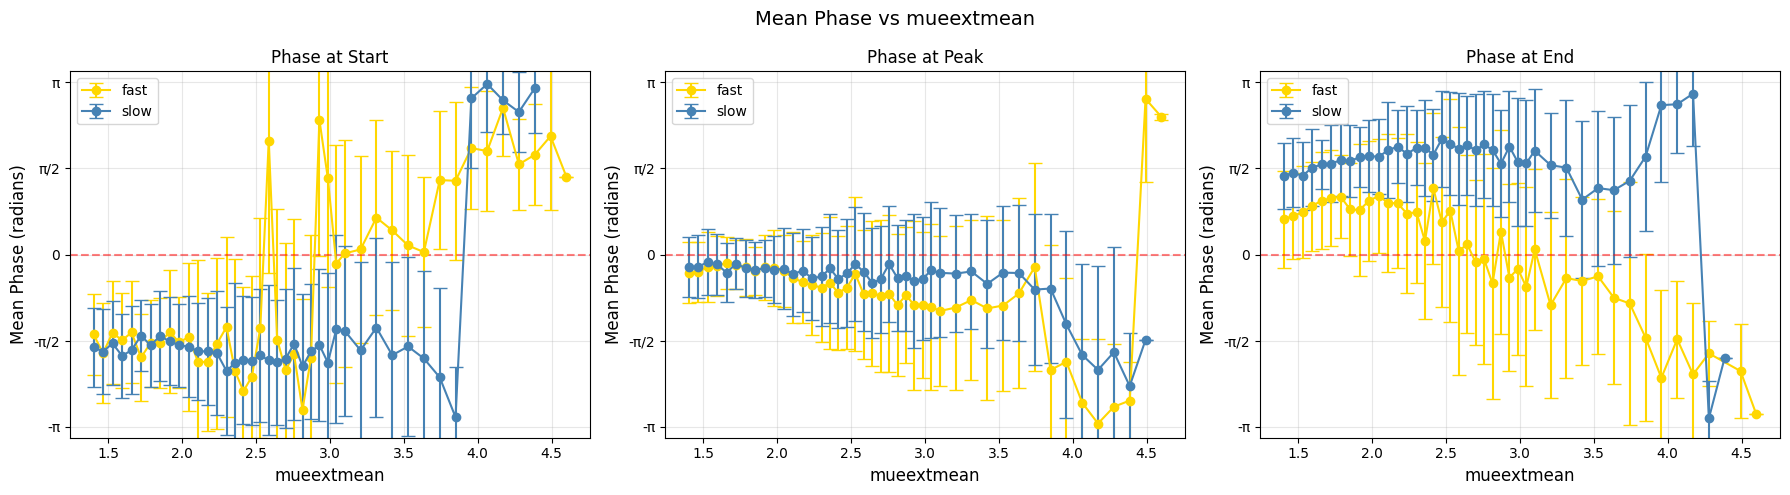


按 seed 统计后的结果示例:
   mueextmean  seed  type  total_duration  count  mean_freq  std_freq  \
0         1.4     1  fast          3.0230      5  13.288183  0.202393   
1         1.4     1  slow          2.6511      3  10.783782  0.370101   
2         1.4     2  fast          3.1521      4  12.601454  0.306260   
3         1.4     2  slow          3.4330      5  11.399272  0.608901   
4         1.4     3  fast          4.7722      6  12.428915  0.275220   

   mean_duration  std_duration  
0       0.604600      0.294453  
1       0.883700      0.507597  
2       0.788025      0.284435  
3       0.686600      0.675367  
4       0.795367      0.345914  

汇总统计示例:
   mueextmean  type  mean_total_duration  std_total_duration  mean_count  \
0      1.4000  fast             4.237340            1.183136        5.85   
1      1.4000  slow             3.985675            1.001956        5.85   
2      1.4643  fast             3.819525            1.127215        5.45   
3      1.4643  slow             

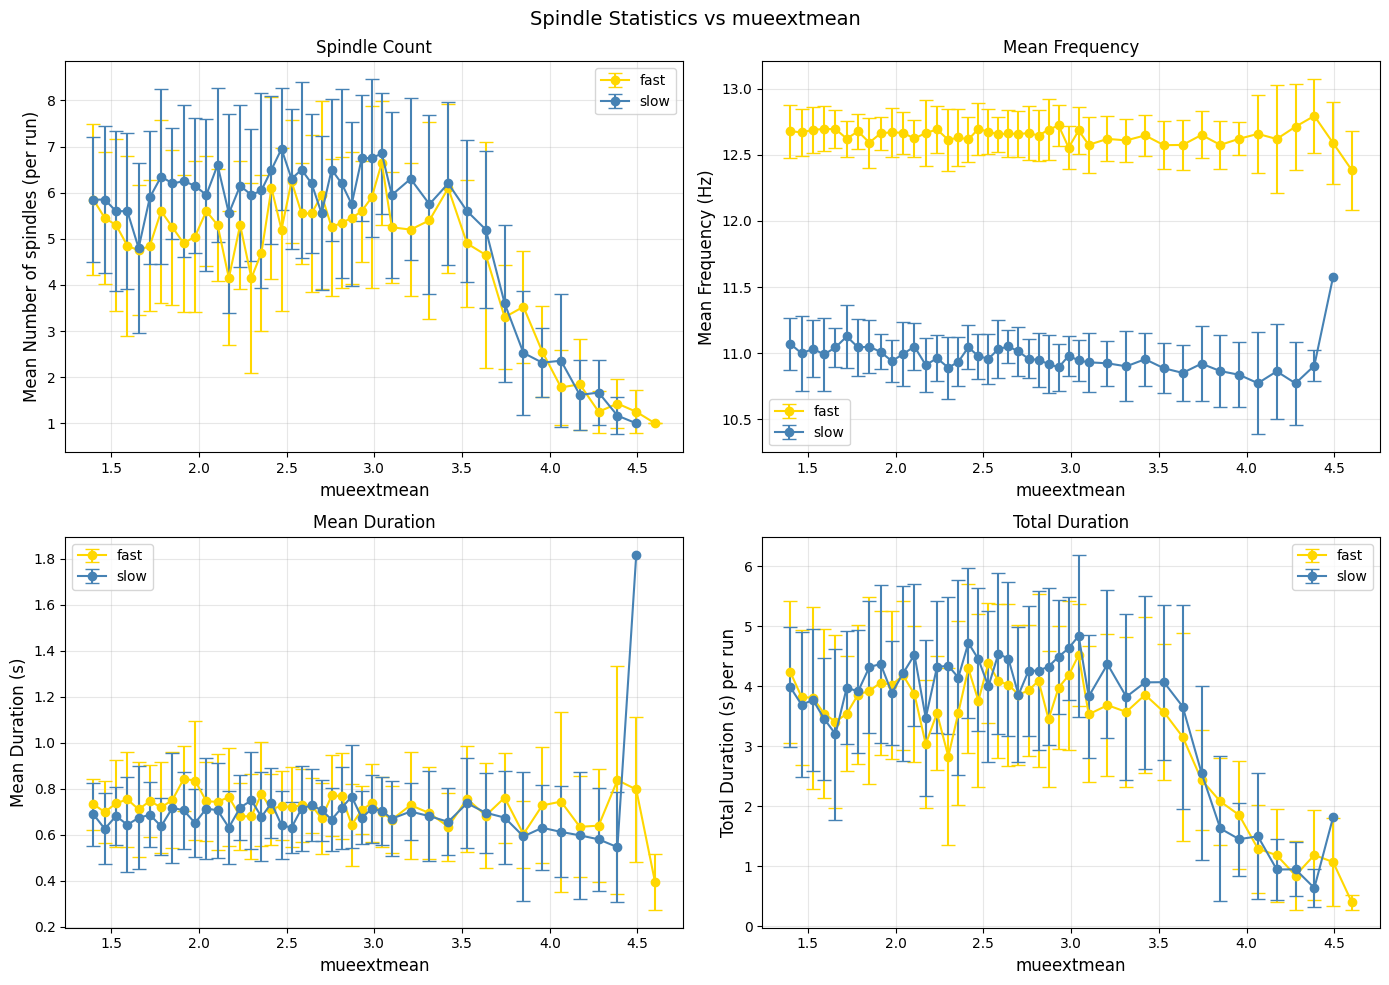


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  mueextmean=1.40: seeds=20, count=5.8±1.6, total_dur=4.24±1.18s, freq=12.68±0.20Hz, dur=0.732±0.112s, phase=-0.330±0.551rad
  mueextmean=1.46: seeds=20, count=5.5±1.4, total_dur=3.82±1.13s, freq=12.67±0.18Hz, dur=0.699±0.136s, phase=-0.322±0.544rad
  mueextmean=1.53: seeds=20, count=5.3±1.9, total_dur=3.81±1.52s, freq=12.69±0.18Hz, dur=0.737±0.190s, phase=-0.228±0.636rad
  mueextmean=1.59: seeds=20, count=4.8±2.0, total_dur=3.54±1.41s, freq=12.70±0.17Hz, dur=0.754±0.207s, phase=-0.210±0.542rad
  mueextmean=1.66: seeds=20, count=4.8±1.4, total_dur=3.41±1.44s, freq=12.69±0.14Hz, dur=0.710±0.206s, phase=-0.148±0.474rad
  mueextmean=1.72: seeds=20, count=4.8±1.4, total_dur=3.54±0.96s, freq=12.62±0.14Hz, dur=0.747±0.155s, phase=-0.182±0.455rad
  mueextmean=1.79: seeds=20, count=5.6±2.0, total_dur=3.86±1.16s, freq=12.68±0.13Hz, dur=0.719±0.198s, phase=-0.235±0.516rad
  mueextmean=1.85: seeds=20, count=5.2±1.7, total_dur=3.93±1.56s, freq=12.59±0.19Hz,

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "mueextmean"   # 可选: "mueextmean", "tau_ou", "tau_se", "cee"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mueextmean": {
        "file": "spindles_mueextmean_explore_valid_limited.csv",
        "xlabel": "mueextmean",
        "save_prefix": "mueextmean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
}

# 获取当前配置
config = PARAM_CONFIG[PARAM_TYPE]
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

# ========== 以下代码完全不用改 ==========
df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# 图1：平均相位（一行三列）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 先计算每个 seed 的统计量，再求平均 ==========
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
).reset_index()

summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图2：四张汇总图（改成 2行 x 2列）==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2行2列，整体更大
axes = axes.flatten()  # 展平方便索引

# 子图1：平均纺锤波数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# 打印统计摘要
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")